In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
in_path = "../../data/Fig3_beta_posterior_bands.csv"

df = pd.read_csv(in_path, comment="#")

x_pred = df["z"].to_numpy()

# Posterior median
y_median = df["beta_median"].to_numpy()

# Percentile bands with 68% and 95% credible interval
y_lower_68_pct = df["beta_68_lower"].to_numpy()
y_upper_68_pct = df["beta_68_upper"].to_numpy()
y_lower_95_pct = df["beta_95_lower"].to_numpy()
y_upper_95_pct = df["beta_95_upper"].to_numpy()


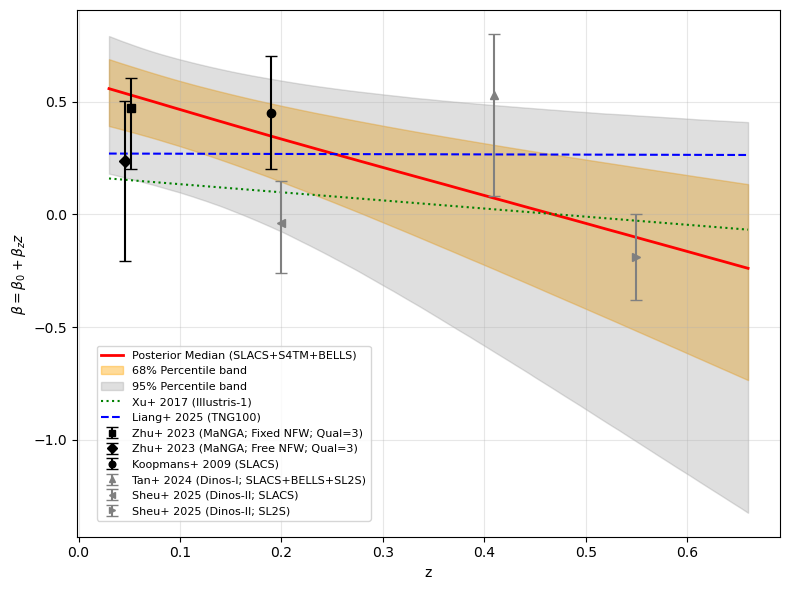

In [3]:
x_sim = x_pred
y_sim_ill = 0.17-0.36*x_sim
y_sim_tng = 0.27-0.01*x_sim

# Visual comparison
fig, axes = plt.subplots(1, 1, figsize=(8, 6))

# Posterior median
ax3 = axes
ax3.plot(x_pred, y_median, 'r-', linewidth=2, label='Posterior Median (SLACS+S4TM+BELLS)') #Median prediction

ax3.fill_between(x_pred, y_lower_68_pct, y_upper_68_pct, 
                alpha=0.4, color='orange', label='68% Percentile band')
ax3.fill_between(x_pred, y_lower_95_pct, y_upper_95_pct, 
                alpha=0.25, color='grey', label='95% Percentile band')#light grey

ax3.plot(x_sim, y_sim_ill, ':', label='Xu+ 2017 (Illustris-1)', color='green')
ax3.plot(x_sim, y_sim_tng, '--', label='Liang+ 2025 (TNG100)', color='blue')

z0 = 0.049+0.003 #median redshift
beta0 = 0.470
yerr_asym = np.array([[0.269], [0.134]])  # 
ax3.errorbar(z0, beta0, yerr=yerr_asym, fmt='s', color='k', ecolor='k', capsize=4, label='Zhu+ 2023 (MaNGA; Fixed NFW; Qual=3)') 

z0 = 0.049-0.003 #median redshift
beta0 = 0.235
yerr_asym = np.array([[0.443], [0.267]])  # 
ax3.errorbar(z0, beta0, yerr=yerr_asym, fmt='D', color='k', ecolor='k', capsize=4, label='Zhu+ 2023 (MaNGA; Free NFW; Qual=3)') 

z0 = 0.19 #median redshift
beta0 = 0.45
yerr_asym = np.array([[0.250], [0.25]])  # lower error = 0.250, upper error = 0.25
ax3.errorbar(z0, beta0, yerr=yerr_asym, fmt='o', color='k', ecolor='k', capsize=4, label='Koopmans+ 2009 (SLACS)') #Using the PL density profile and luminosity-mass relation; 58 SLACS

z0 = 0.41 #median redshift
beta0 = 0.53
yerr_asym = np.array([[0.45], [0.27]])  # lower error = 0.45，upper error = 0.27
ax3.errorbar(z0, beta0, yerr=yerr_asym, fmt='^', color='grey', ecolor='grey', capsize=4, label='Tan+ 2024 (Dinos-I; SLACS+BELLS+SL2S)') #34 SLACS + 24 SL2S + 19 BELLS

z0 = 0.2 #median redshift
beta0 = -0.04
yerr_asym = np.array([[0.22], [0.19]])  # lower error = 0.22，upper error = 0.19
ax3.errorbar(z0, beta0, yerr=yerr_asym, fmt='<', color='grey', ecolor='grey', capsize=4, label='Sheu+ 2025 (Dinos-II; SLACS)') #33 SLACS

z0 = 0.55 #median redshift
beta0 = -0.19
yerr_asym = np.array([[0.19], [0.19]])  # lower error = 0.19，upper error = 0.19
ax3.errorbar(z0, beta0, yerr=yerr_asym, fmt='>', color='grey', ecolor='grey', capsize=4, label='Sheu+ 2025 (Dinos-II; SL2S)') #23 SL2S

# z0 = 0.275#median redshift
# beta0 = -0.2
# yerr_asym = np.array([[0.19], [0.21]])  # lower error = 0.19，upper error = 0.19
# ax3.errorbar(z0, beta0, yerr=yerr_asym, fmt='v', color='grey', ecolor='grey', capsize=4, label='Sheu+ 2025 (Dinos-II; 0.09<z<0.88)') #23 SL2S

ax3.set_xlabel('z')
ax3.set_ylabel(f'$\\beta=\\beta_0+\\beta_z z$')
#ax3.set_title('The redshift evolution of stellar orbital anisotropy')
ax3.legend(fontsize=8,markerscale=0.8,loc='lower left',bbox_to_anchor=(0.02, 0.02))
ax3.grid(True, alpha=0.3)
#ax3.set_xlim(0.02, 0.69)

plt.tight_layout()
# plt.savefig("img_beta_z.png", dpi=300, bbox_inches="tight")
# plt.show()
plt.savefig('img_beta_z.pdf', dpi=400, bbox_inches='tight')
#plt.savefig('img_beta_z.png', dpi=400, bbox_inches='tight')
plt.show()


| Sample | num | mean z | median z | min z | max z |  
|------|-----|------|--------|-----|-----|  
| This work (63 SLACS + 38 S4TM + 20 BELLS) | 121 | 0.246 | 0.205 | 0.062 | 0.659 |
| Zhu (371 nearby galaxies from MaNGA) | 371 | 0.055 | 0.049 | 0.020 | 0.150 | 
| Koopmans (58 SLACS) | 58 | 0.197 | 0.190 | 0.062 | 0.358 |  
| Dinos-I (34 SLACS + 24 SL2S + 19 BELLS) | 77 | 0.387 | 0.410 | 0.090 | 0.780 |  
| Dinos-II (33 SLACS) | 33 | 0.218 | 0.200 | 0.090 | 0.440 |  
| Dinos-II (23 SL2S) | 23 | 0.549 | 0.552 | 0.270 | 0.884 |
| Dinos-II (33 SLACS + 22 SL2S) | 56 | 0.354 | 0.275 | 0.090 | 0.884 |
